In [20]:
import os
os.environ["OMP_NUM_THREADS"] = "6"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

from collections import Counter
from scipy.stats import chi2_contingency

In [21]:
df = (
    pd.read_csv("data/ab_ag_annotated_test.tsv", sep="\t")
    .dropna(subset = regions)
    .drop_duplicates(subset = regions)
    .reset_index(drop = True)
)
regions = ["CDR_H1", "CDR_H2", "CDR_L1", "CDR_L2", "CDR_L3"]
antigen_labels = df["antigen_name"].tolist()

In [22]:
feature_spaces = {}
for region in regions:
    fs_rows = []
    for df_row in df.itertuples():
        # Metadaten der PDB-Einträge
        pdb = df_row.pdb
        antigen_name = df_row.antigen_name
        antigen_species = df_row.antigen_species

        # Embedding-Koordinaten der PDB-Einträge
        embedding_as_arr = np.load(f"data/embeddings/{pdb}/{pdb}_{region}.npy")
        #embedding_as_vec = embedding_as_arr.mean(axis=0)
        embedding_as_vec = PCA(n_components=1).fit_transform(embedding_as_arr.T).flatten()

        # Erstellen und Anhängen der Zeile eines PDB-Eintrages für den Feature-Space
        fs_row = [pdb] + [antigen_name] + [antigen_species] + embedding_as_vec.tolist()
        fs_rows.append(fs_row)
    
    # Umwandeln des Feature-Space von einer List in einen DataFrame
    feature_space = pd.DataFrame(fs_rows, columns = ["pdb"] + ["antigen_name"] + ["antigen_species"] + [f"embedding_dimension {e}" for e in range(embedding_as_vec.shape[0])])
    feature_spaces[region] = feature_space

IndexError: index 542 is out of bounds for axis 0 with size 6

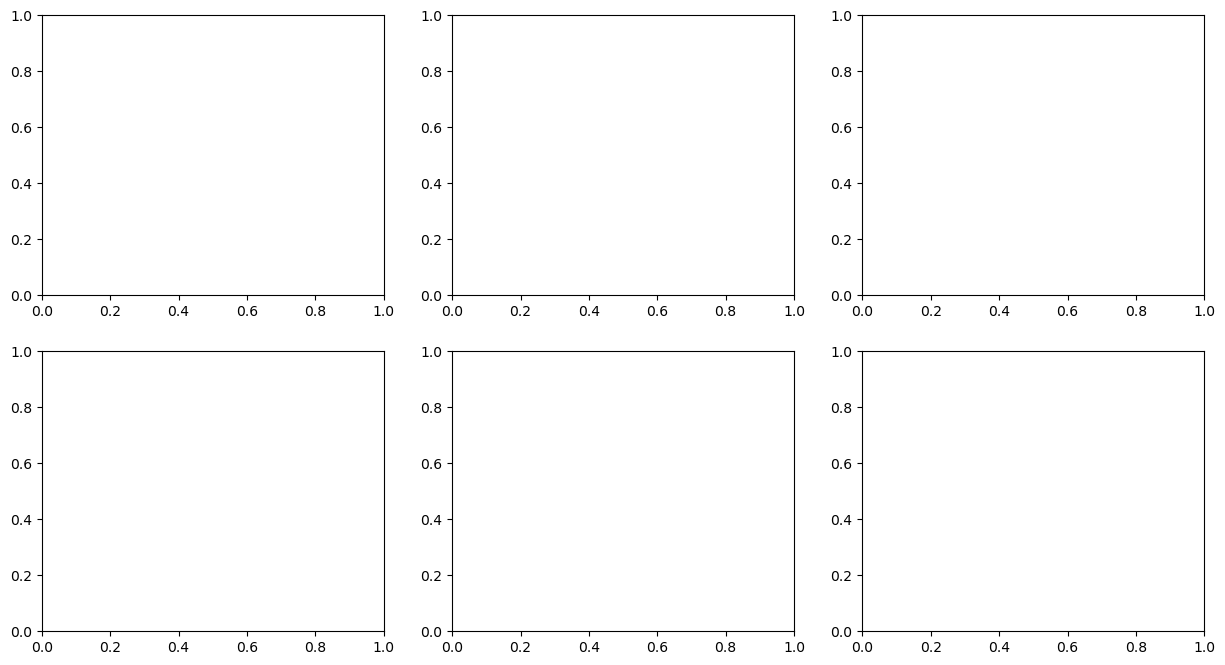

In [23]:
from data_cleanup.functions import show_PCA
show_PCA(feature_spaces)

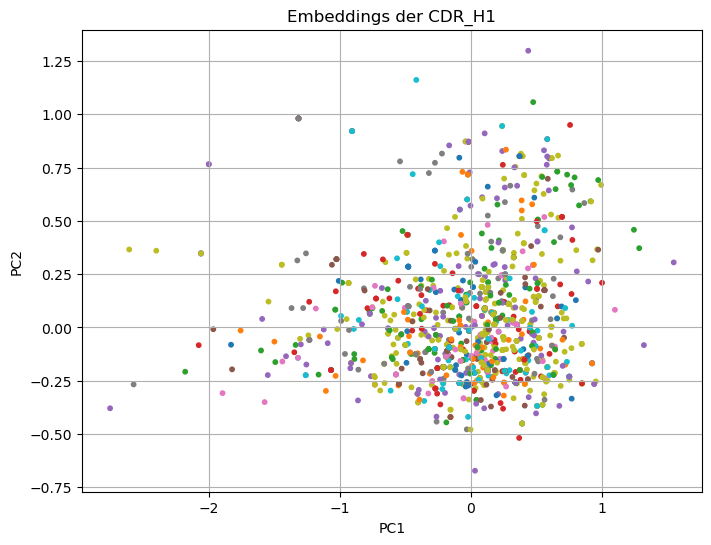

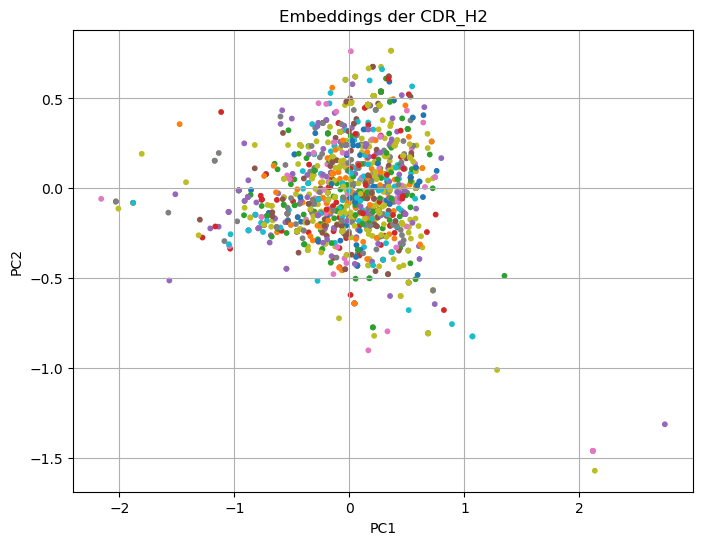

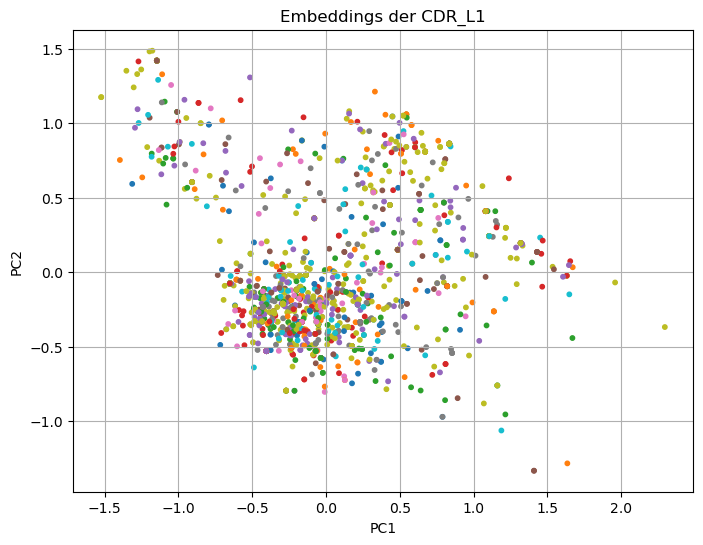

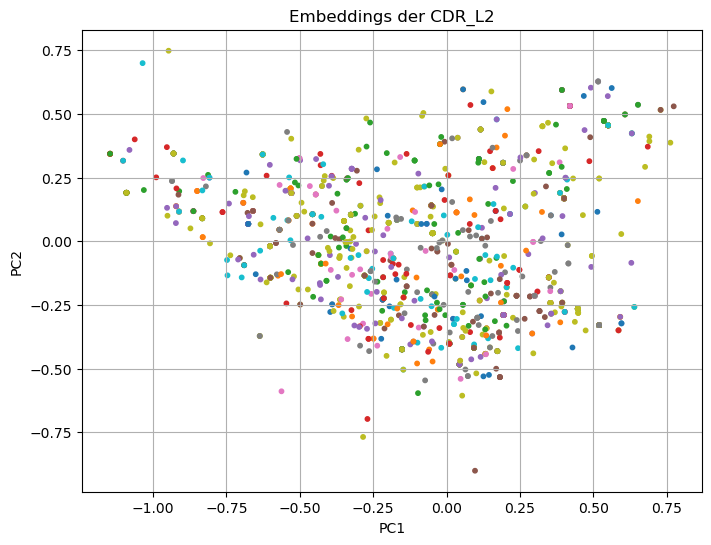

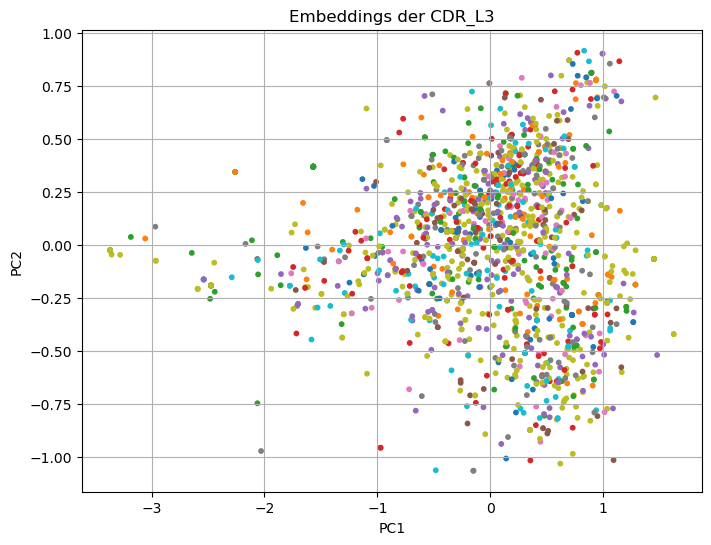

In [ ]:
# Visualisierung der Embeddings in 2D mit PCA    
for region in regions:
    feature_space = feature_spaces[region]    
    X = feature_space.drop(columns=["pdb"] + ["antigen_name"] + ["antigen_species"]).values
    X_2d = PCA(n_components=2).fit_transform(X)
    plt.figure(figsize=(8, 6))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=pd.Categorical(feature_space["antigen_name"]).codes, cmap='tab10', s=10)
    plt.title(f"Embeddings der {region}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()

    #labels = KMeans(n_clusters=10, random_state=42).fit_predict(X) (für KMeans-Clustering)


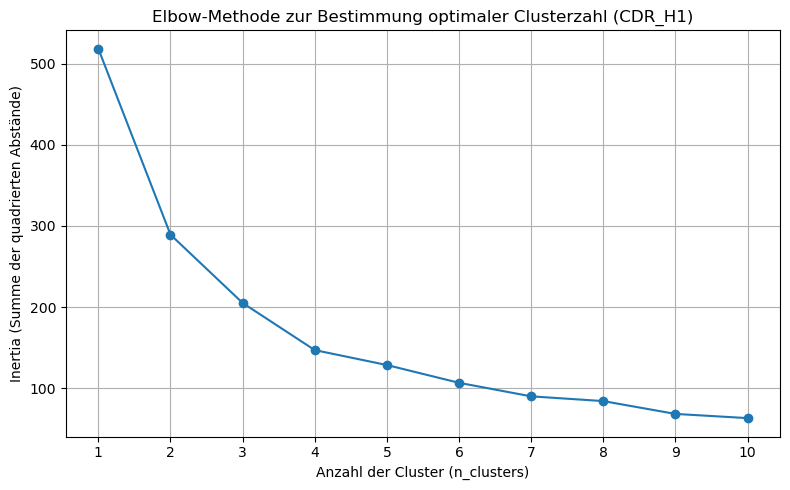

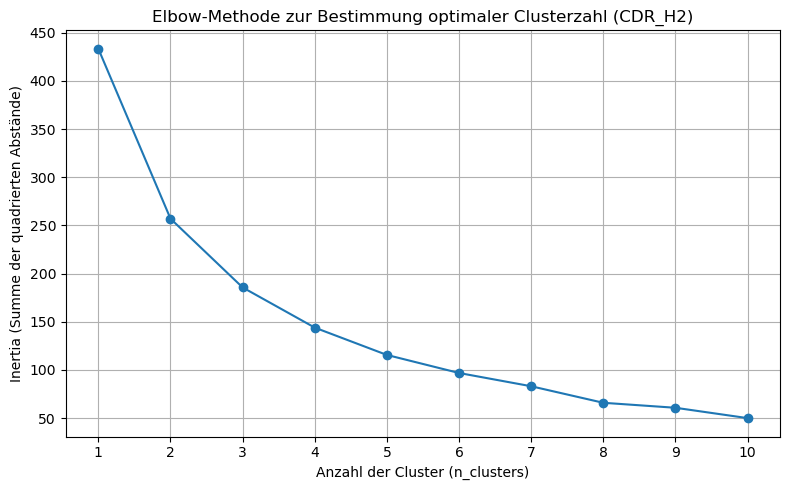

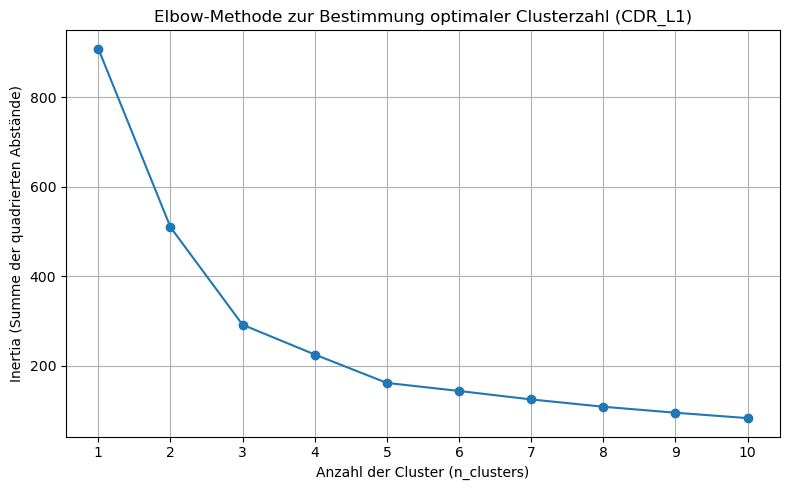

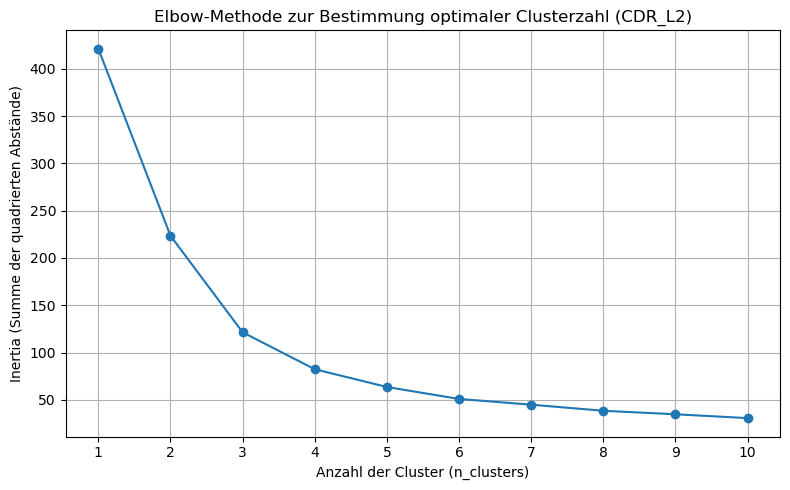

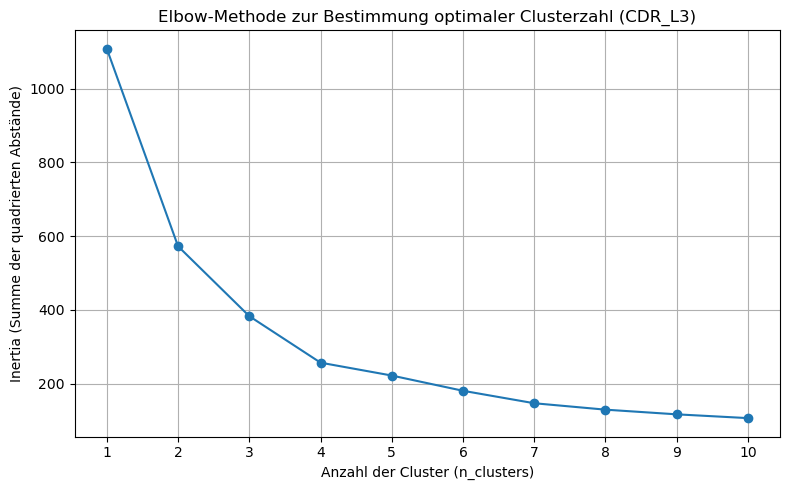

In [ ]:
# Elbow-Methode zur Bestimmung der optimalen Clusterzahl

for region in regions:
    feature_space_elbow = feature_spaces[region]

    #berücksichtigt nur top 10 aufgrund wie feature space definiert wurde
    X = feature_space_elbow.drop(columns = ["pdb", "antigen_name", "antigen_species"])
    coords = PCA(n_components=2).fit_transform(X)

    # Range of cluster numbers to try
    cluster_range = range(1, 11)  # Teste 1-10 Cluster

    # Hier Inertia-Werte speichern, [] für liste
    #inertia => Summe der quadrierten Abstände der Punkte zum jeweiligen Cluster-Zentrum => je kleiner, desto besser
    inertia_values = []

    # Berechne KMeans für jede Cluster-Anzahl
    for n_clusters in cluster_range:
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        kmeans.fit(coords)  # fit passt daten an modell an => kmeans bekommt daten (coords der antikörper punkte) und initialisiert Cluster Zentren und macht dann iterative optimierung 
        # also weist punkte dem nächsten cluster zentrum zu, bei den gebildeten cluster wenn neue zentren berechnet und die punkte werden neu zugeordnet
        inertia_values.append(kmeans.inertia_)

    # Plot der Elbow-Kurve
    plt.figure(figsize=(8, 5))
    plt.plot(cluster_range, inertia_values, marker='o')
    plt.xlabel('Anzahl der Cluster (n_clusters)')
    plt.ylabel('Inertia (Summe der quadrierten Abstände)')
    plt.title(f'Elbow-Methode zur Bestimmung optimaler Clusterzahl ({region})')
    plt.xticks(cluster_range) #x achse werden dann anzhal cluster gezeigt
    plt.grid(True) #gitternetzlinien im plot
    plt.tight_layout()
    plt.show()


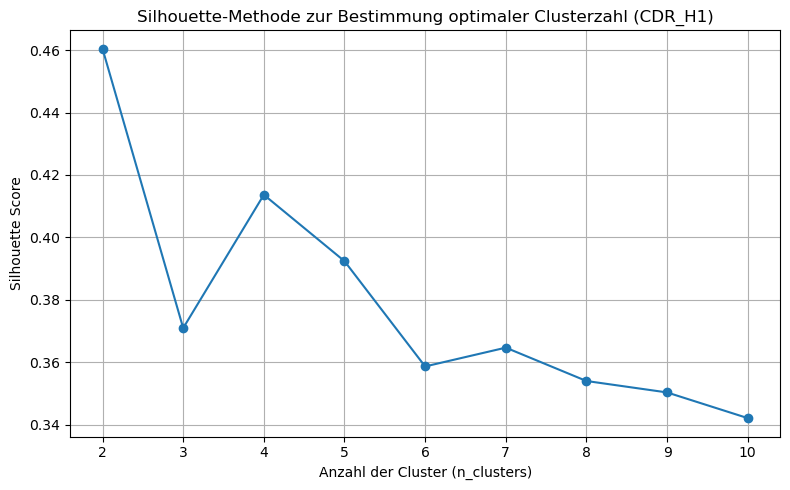

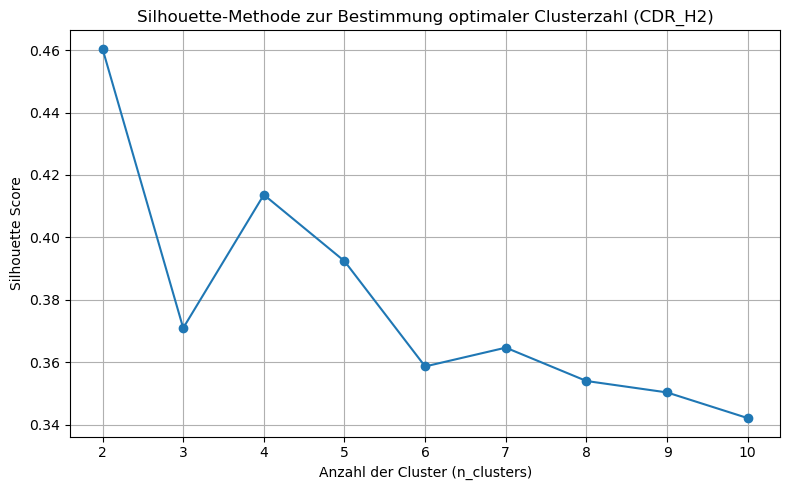

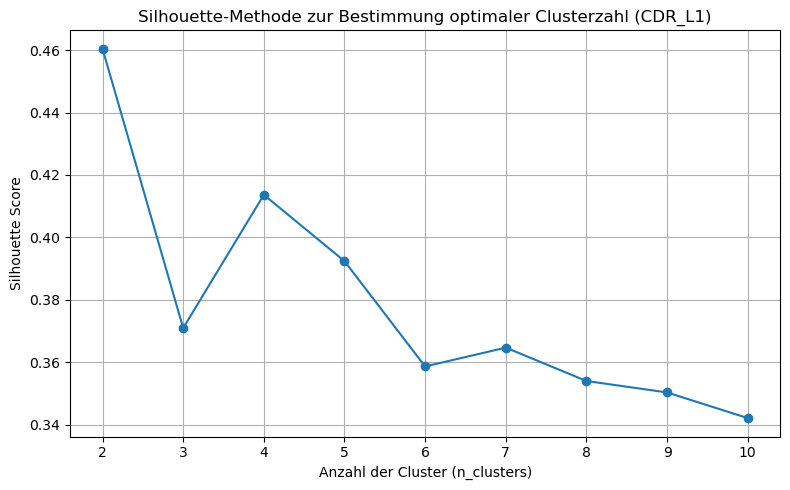

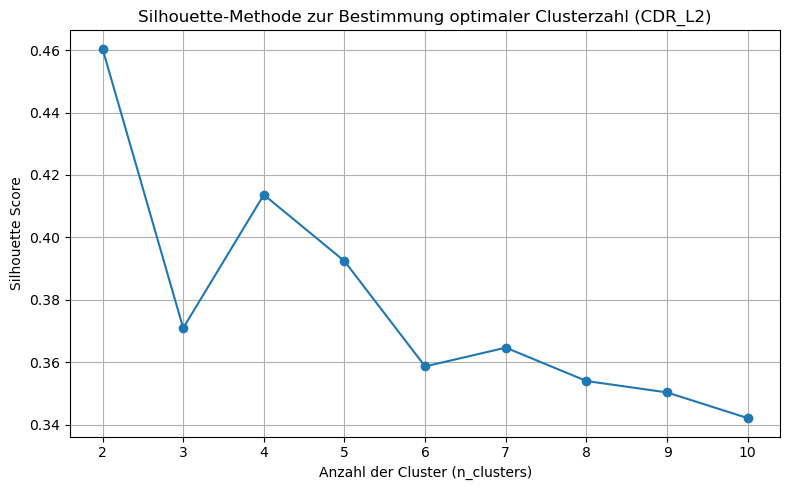

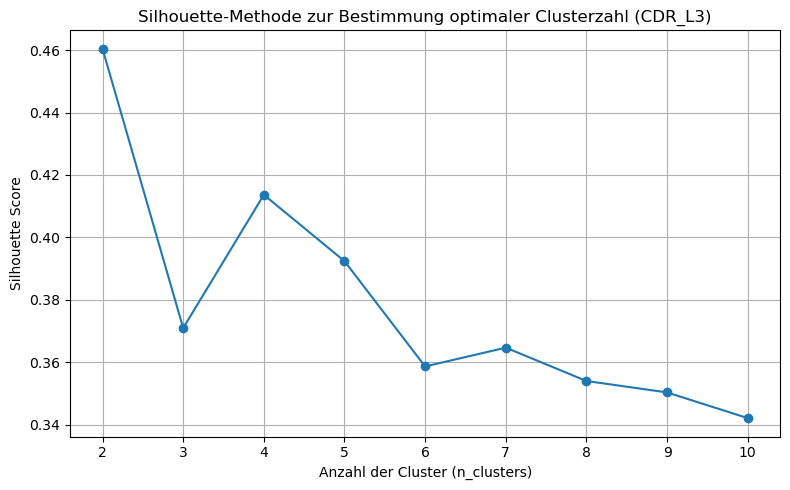

In [ ]:
# Silhouette-Methode zur Bestimmung der optimalen Clusterzahl

for region in regions:
    feature_space_silhouette = feature_spaces[region]
    
    #berücksichtigt nur top 10 aufgrund wie feature space definiert wurde
    X = feature_space_elbow.drop(columns = ["pdb", "antigen_name", "antigen_species"])
    coords = PCA(n_components=2).fit_transform(X)

    # Cluster-Range
    cluster_range = range(2, 11)
    silhouette_values = []

    # Berechne Silhouette Score für jede Clusteranzahl
    for n_clusters in cluster_range:
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        labels = kmeans.fit_predict(coords)
        score = silhouette_score(coords, labels)
        silhouette_values.append(score)

    # Plot Silhouette-Kurve
    plt.figure(figsize=(8, 5))
    plt.plot(cluster_range, silhouette_values, marker='o')
    plt.xlabel('Anzahl der Cluster (n_clusters)')
    plt.ylabel('Silhouette Score')
    plt.title(f'Silhouette-Methode zur Bestimmung optimaler Clusterzahl ({region})')
    plt.grid(True)
    plt.xticks(cluster_range)
    plt.tight_layout()
    plt.show()


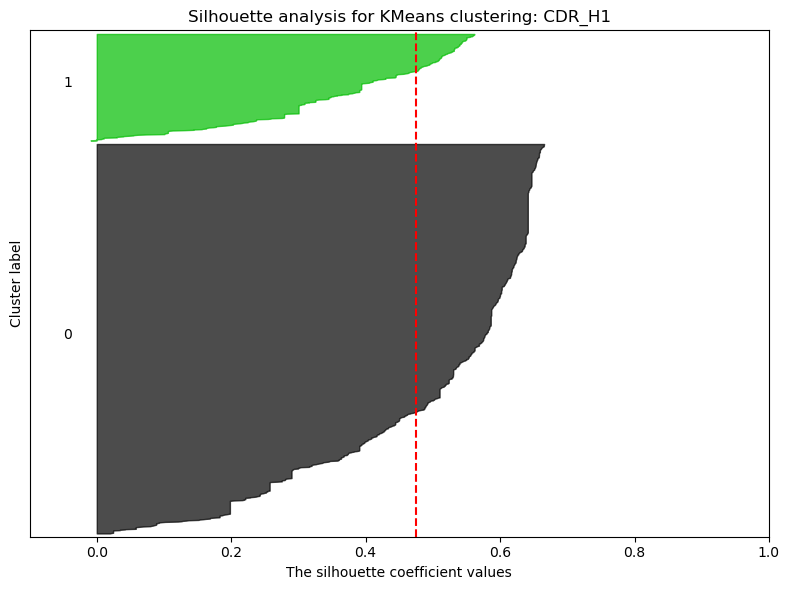

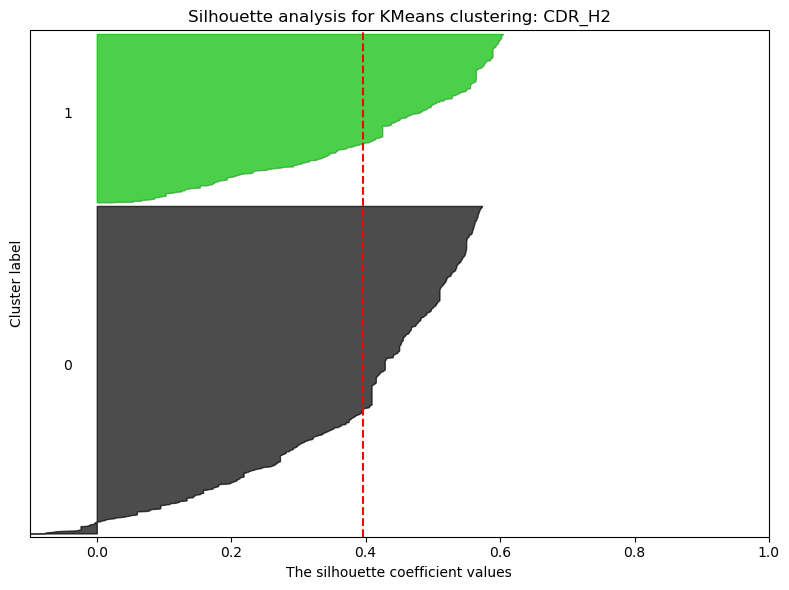

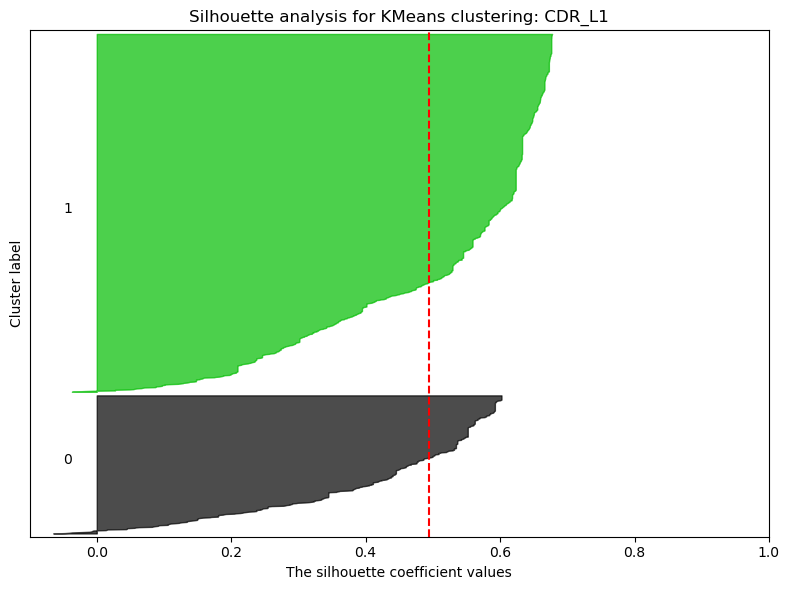

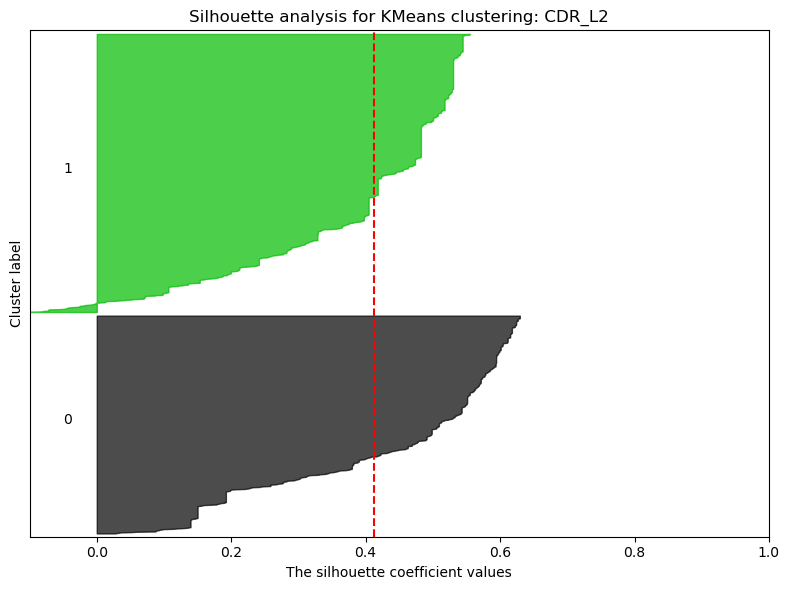

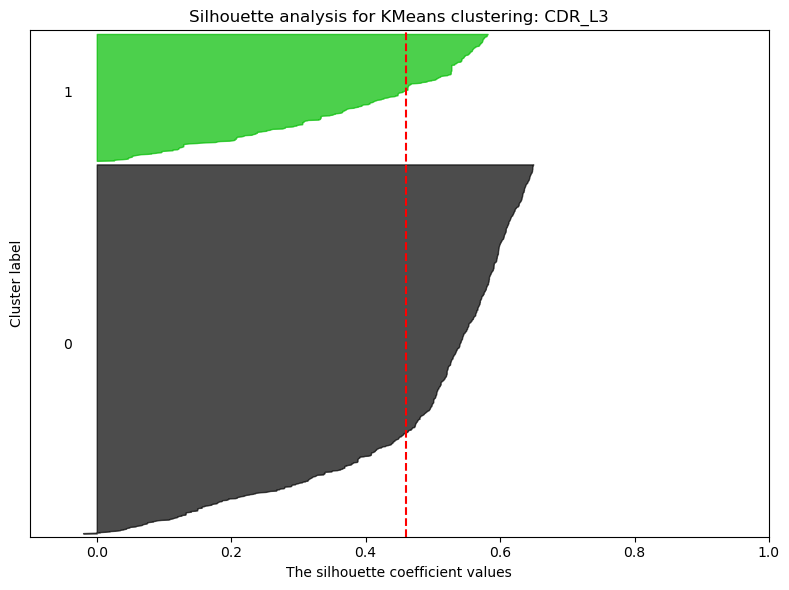

In [ ]:
# Silhouette-Methode zur Bestimmung der optimalen Clusterzahl
for region in regions:
    feature_space_silhouette = feature_spaces[region]
    X = feature_space_silhouette.drop(columns=["pdb", "antigen_name", "antigen_species"])
    coords = PCA(n_components=2).fit_transform(X)
    
    # Nutze 2D-PCA-Koordinaten für Visualisierung + Silhouette
    coords = PCA(n_components=2).fit_transform(X)
    n_clusters = 2  # kann angepasst werden
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(coords)

    # Silhouette-Berechnung

    # Cluster-Range
 
    silhouette_avg = silhouette_score(coords, cluster_labels)
    sample_silhouette_values = silhouette_samples(coords, cluster_labels)

    # Plot
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(8, 6)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7
        )

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_title(f"Silhouette analysis for KMeans clustering: {region}")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")
    ax1.set_yticks([])
    ax1.set_xlim([-0.1, 1.0])
    ax1.set_ylim([0, len(coords) + (n_clusters + 1) * 10])
    plt.tight_layout()
    plt.show()

       pdb                                       antigen_name  \
0     9ds2   hemagglutinin ha2 chain | hemagglutinin ha1 chai   
1     8uzp                                    stem_mimetic_01   
2     8veb                                      hemagglutinin   
3     8ved                                      hemagglutinin   
4     8vef                                      hemagglutinin   
...    ...                                                ...   
1502  7n3d                                      nucleoprotein   
1503  4od2  tumor necrosis factor receptor superfamily mem...   
1504  3q1s                                     interleukin-22   
1505  5sy8                       10e8 epitope scaffold t117v2   
1506  4ps4                                     interleukin-13   

                                      antigen_species  embedding_dimension 0  \
0               influenza a virus | influenza a virus               0.023762   
1                                        mus musculus      

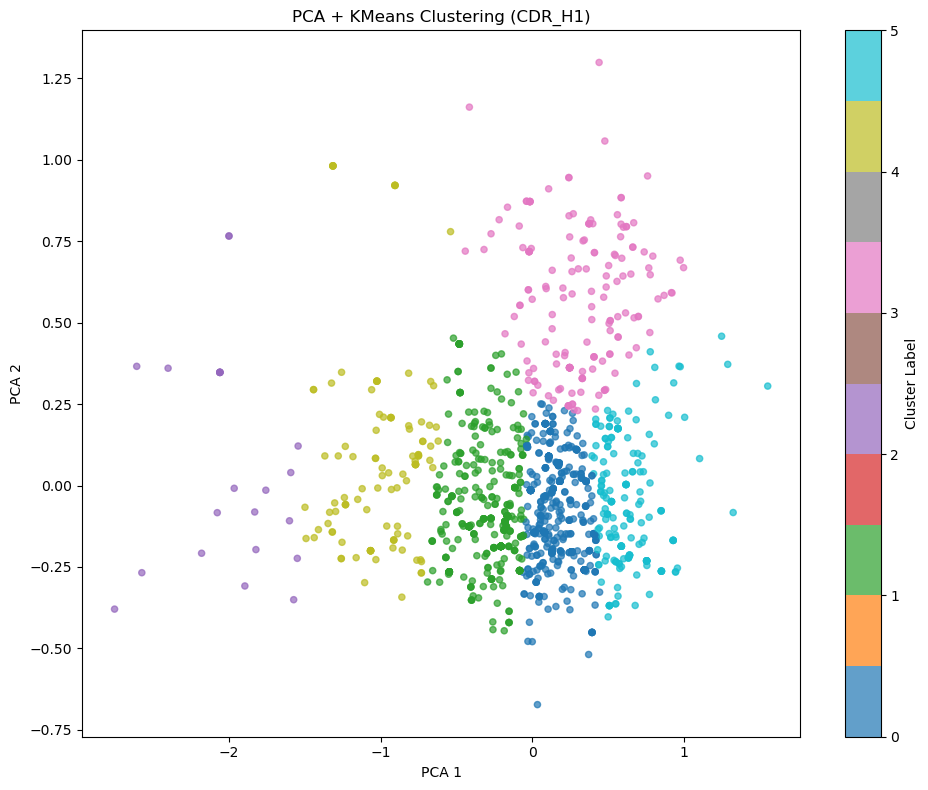


 Antigen Häufigkeiten pro Cluster für CDR_H1 

Cluster 0:
  spike protein s1: 100x
  spike glycoprotein: 90x
  hemagglutinin: 16x
  surface glycoprotein: 12x
  gametocyte surface protein p230: 10x
  neuraminidase: 8x
  hemagglutinin | hemagglutinin: 7x
  programmed cell death protein 1: 7x
  circumsporozoite protein: 7x
  envelope glycoprotein e2: 6x
  iron-regulated surface determinant protein b: 6x
  spike protein: 5x
  clade a/e 93th057 hiv-1 gp120 core: 5x
  tyrosine-protein phosphatase non-receptor type substrate 1: 5x
  hemagglutinin ha1 chain: 4x
  fusion glycoprotein f0: 4x
  e2 glycoprotein: 4x
  spike glycoprotein | spike glycoprotein: 4x
  interleukin-17a: 4x
  unknown: 4x
  granulocyte-macrophage colony-stimulating factor: 4x
  cytotoxic t-lymphocyte protein 4: 3x
  receptor tyrosine-protein kinase erbb-3: 3x
  tumor necrosis factor receptor superfamily member 5: 3x
  tumor necrosis factor receptor superfamily member 10b: 3x
  sars-cov-2 spike glycoprotein: 3x
  lysozyme c

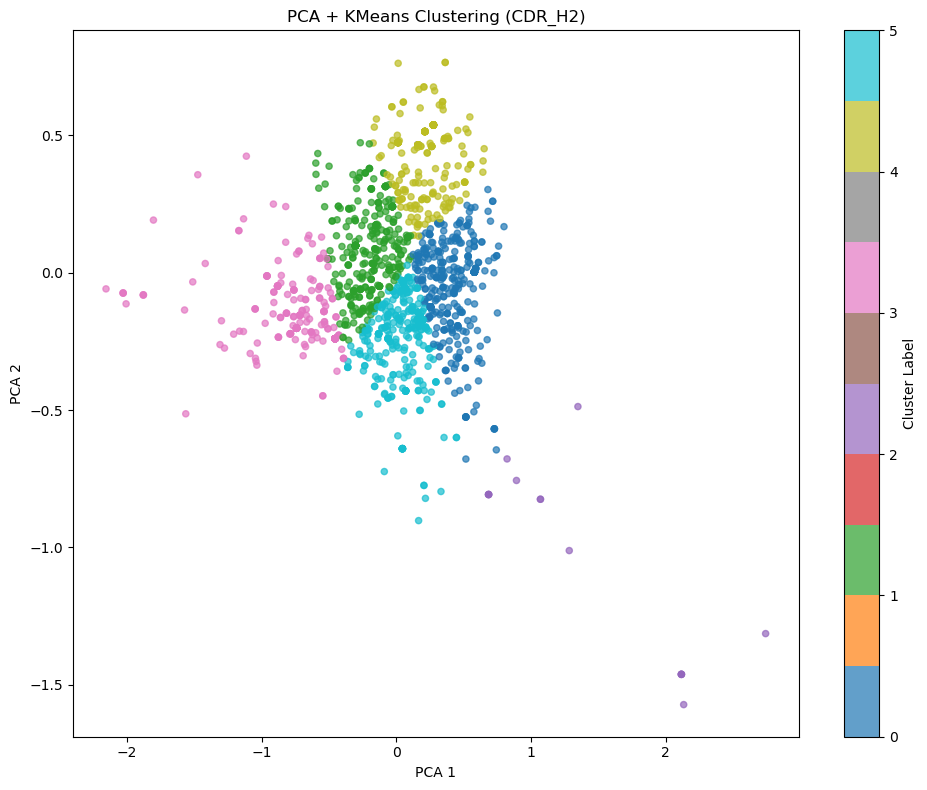


 Antigen Häufigkeiten pro Cluster für CDR_H2 

Cluster 0:
  spike glycoprotein: 50x
  spike protein s1: 38x
  hemagglutinin: 11x
  neuraminidase: 9x
  outer surface protein a: 6x
  fusion glycoprotein f0: 5x
  receptor tyrosine-protein kinase erbb-2: 4x
  envelope glycoprotein e2: 4x
  10e8 epitope scaffold t117v2: 4x
  hemagglutinin ha1 chain: 3x
  envelope glycoprotein b: 3x
  spike glycoprotein | spike glycoprotein: 3x
  gametocyte surface protein p230: 3x
  envelope protein e: 3x
  hemagglutinin ha2 chain | hemagglutinin ha1 chain: 3x
  envelope glycoprotein gp160: 3x
  surface glycoprotein: 3x
  gametocyte surface protein p45/48: 2x
  5'-nucleotidase: 2x
  cytotoxic t-lymphocyte protein 4: 2x
  adp-ribosyl cyclase/cyclic adp-ribose hydrolase 1: 2x
  hemagglutinin | hemagglutinin: 2x
  bg505 ds-sosip transmembrane protein gp41 | bg505 ds-sosip surface protein gp120: 2x
  9mer peptide,beta-2-microglobulin,mhc class i antigenchimera : 2x
  transforming growth factor beta-1 proprotei

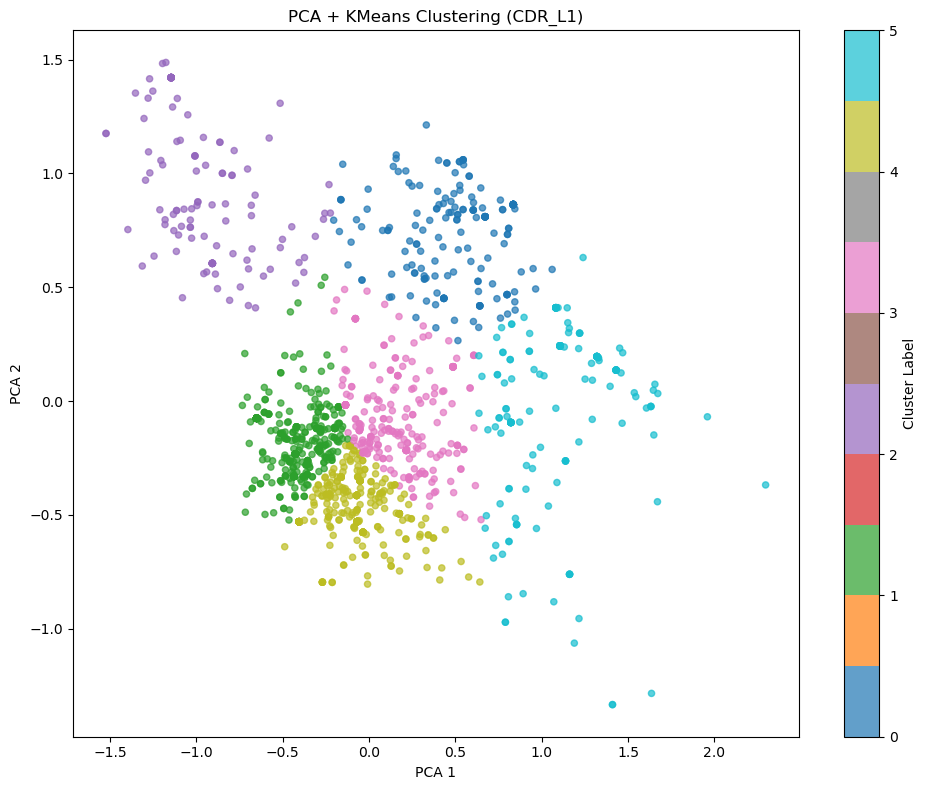


 Antigen Häufigkeiten pro Cluster für CDR_L1 

Cluster 0:
  spike protein s1: 37x
  spike glycoprotein: 26x
  hemagglutinin: 7x
  ch848.10.17 gp120: 6x
  envelope glycoprotein b: 4x
  neuraminidase: 4x
  ch848.10.17.sosip gp120: 4x
  sars-cov-2 spike glycoprotein: 4x
  programmed cell death protein 1: 3x
  envelope glycoprotein gp120: 3x
  vp1: 2x
  envelope protein: 2x
  spike glycoprotein,fibritin,expression tag: 2x
  igg receptor fcrn large subunit p51 | beta-2-microglobulin: 2x
  glycoprotein g2 | glycoprotein g2 | glycoprotein g2: 2x
  spike glycoprotein,fibritin: 2x
  fusion glycoprotein f0: 2x
  envelope glycoprotein gp160: 2x
  hemagglutinin ha1: 2x
  surface glycoprotein: 2x
  reticulocyte binding protein 2b: 2x
  unknown | pre-glycoprotein polyprotein gp complex: 2x
  ige fc: 2x
  c-x-c motif chemokine 13: 2x
  clade a/e 93th057 hiv-1 gp120 core: 2x
  hemagglutinin ha1 chain: 2x
  nsmgngc: 2x
  erythropoietin receptor: 2x
  enterotoxin type b: 1x
  spike glycoprotein,fibriti

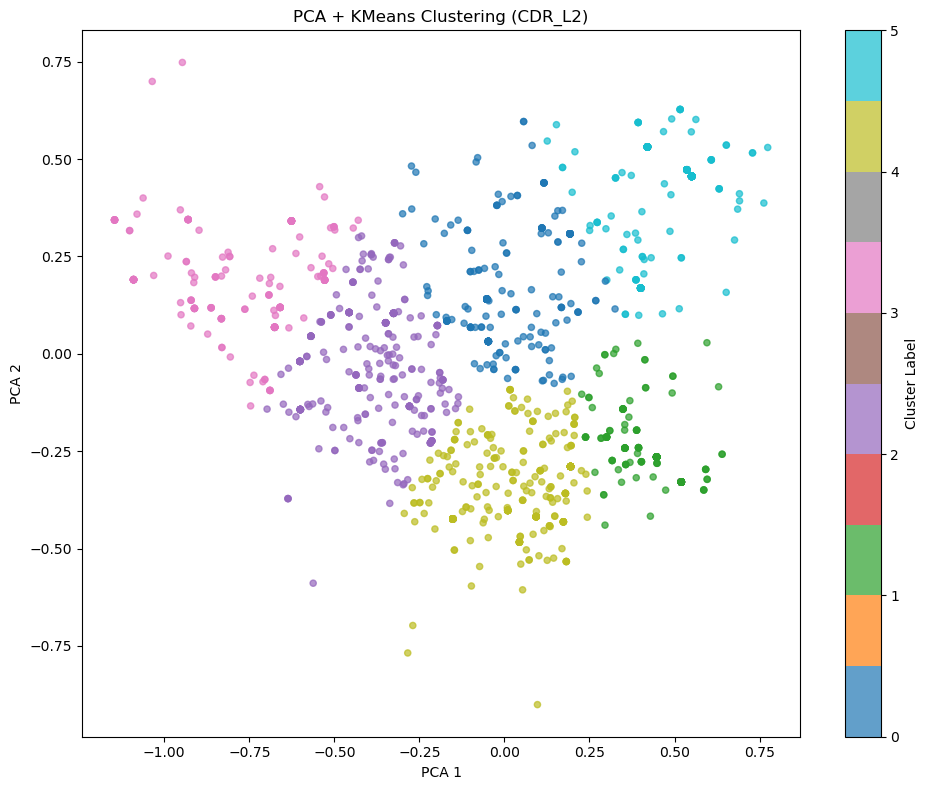


 Antigen Häufigkeiten pro Cluster für CDR_L2 

Cluster 0:
  spike glycoprotein: 32x
  spike protein s1: 22x
  hemagglutinin: 5x
  gametocyte surface protein p230: 5x
  clade a/e 93th057 hiv-1 gp120 core: 5x
  receptor tyrosine-protein kinase erbb-2: 4x
  envelope glycoprotein gp120: 4x
  cytotoxic t-lymphocyte protein 4: 3x
  envelope glycoprotein gp160: 3x
  hemagglutinin ha1: 3x
  surface glycoprotein: 3x
  5'-nucleotidase: 2x
  igg receptor fcrn large subunit p51 | beta-2-microglobulin: 2x
  neuraminidase: 2x
  conglutin: 2x
  glycoprotein g2 | glycoprotein g2 | glycoprotein g2: 2x
  programmed cell death 1 ligand 1: 2x
  spike protein: 2x
  t-cell immunoreceptor with ig and itim domains: 2x
  tumor necrosis factor receptor superfamily member 4: 2x
  unknown: 2x
  beta-mammal toxin cn2: 2x
  interleukin-1 beta: 2x
  envelope protein: 2x
  circumsporozoite protein: 2x
  hemagglutinin ha2 chain | hemagglutinin ha1 chain: 2x
  envelope glycoprotein gp160,envelope glycoprotein gp160: 2

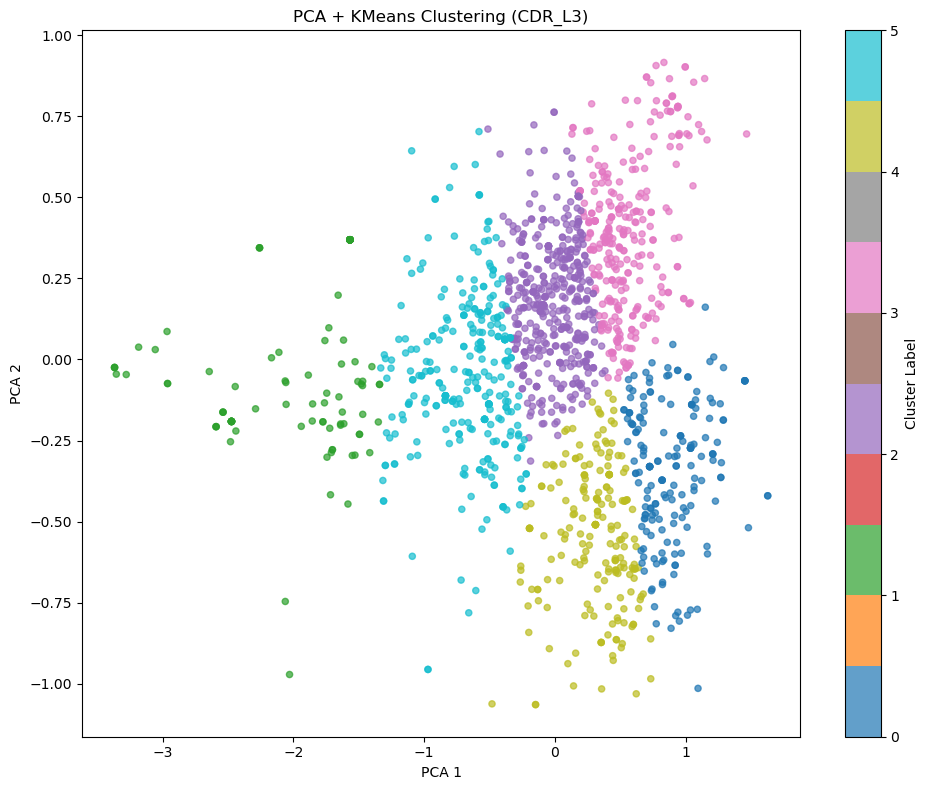


 Antigen Häufigkeiten pro Cluster für CDR_L3 

Cluster 0:
  spike glycoprotein: 26x
  spike protein s1: 23x
  hemagglutinin: 6x
  ch848.10.17 gp120: 6x
  envelope glycoprotein b: 5x
  envelope glycoprotein gp120: 4x
  envelope glycoprotein gp160: 4x
  ch848.10.17.sosip gp120: 4x
  10e8 epitope scaffold t117v2: 4x
  hemagglutinin ha1: 4x
  unknown: 4x
  envelope glycoprotein e: 2x
  neuraminidase: 2x
  receptor tyrosine-protein kinase erbb-3: 2x
  genome polyprotein: 2x
  clade a/e 93th057 hiv-1 gp120 core: 2x
  hemagglutinin ha1 chain: 2x
  circumsporozoite protein: 2x
  granulocyte-macrophage colony-stimulating factor: 2x
  stem_mimetic_01: 1x
  enterotoxin type b: 1x
  vp1: 1x
  major allergen can f 1: 1x
  interferon alpha/beta receptor 1: 1x
  hla class i histocompatibility antigen, a alpha chain | gtpase kras, n-terminally processed: 1x
  hb3var03 cidra1.4 domain: 1x
  erythrocyte membrane protein 1: 1x
  t-cell immunoglobulin mucin receptor 3: 1x
  capsid protein vp1: 1x
  rh5-3

In [ ]:
# Clustering auf basis der PCA
#kmeans mit 2 => laut elbow method am sinnvollsten

antigen_labels = df["antigen_name"].tolist()
for region in regions:
    feature_space_kmeans = feature_spaces[region]

    X = feature_space_kmeans.drop(columns=["pdb", "antigen_name", "antigen_species"])
    coords = PCA(n_components=2).fit_transform(X)
    print(feature_space_kmeans)

    # n_clusters frei wählbar
    kmeans = KMeans(n_clusters=6, random_state=42) #random state wichtig damit auch bei jeden durchlauf gleiche cluster entstehen
    cluster_labels = kmeans.fit_predict(coords) #fit predict führt clustering im 2d pca space durch

    # Plot => Cluster einfärben
    plt.figure(figsize=(10, 8))
    plt.scatter(coords[:, 0], coords[:, 1], c=cluster_labels, cmap='tab10', s=20, alpha=0.7) #c=cöuster labels färbt die punkte nach cluster; tab10 => 10 farben, alpha => tranparenz damit überlappungen sichtbar, s => punktgröße
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.title(f"PCA + KMeans Clustering ({region})")
    plt.colorbar(label='Cluster Label')
    plt.tight_layout()
    plt.show()
        

    #antigen names häufigkeiten in den clustern

    # Erzeuge Mapping: cluster_label → liste von antigen names
    # Dictionary ({} => speichert key => value paare) bauen, in dem für jedes Cluster die Liste der zugehörigen Antigen-Namen gespeichert wird
    cluster_antigen_mapping = {}

    # Gehe alle Punkte durch (alle Antikörper im PCA/Feature-Space)
    # → zip(cluster_labels, antigen_labels) gibt für jeden Punkt: cluster_label: die Cluster-Nummer (z.B. 0, 1, 2, ...) & antigen_name: der Antigen-Name dieses Antikörpers
    for cluster_label, antigen_name in zip(cluster_labels, antigen_labels):

        # Wenn dieses Cluster-Label noch nicht im Dictionary ist => leeres Array initialisieren
        if cluster_label not in cluster_antigen_mapping:
            cluster_antigen_mapping[cluster_label] = []

        # Füge den Antigen-Namen zur Liste für dieses Cluster hinzu
        cluster_antigen_mapping[cluster_label].append(antigen_name)

    #jetzt haben wir für jedes cluster eine liste mit den vorkommenden antigen names

    #für häufigkeiten:
    #header damit klar für welche cdr region
    print(f"\n Antigen Häufigkeiten pro Cluster für {region} ")
    # alle Cluster-Labels sortiert durchgehen
    for cluster_label in sorted(cluster_antigen_mapping.keys()):

        # Drucke Cluster-Header
        print(f"\nCluster {cluster_label}:")

        # wie oft jeder Antigen-Name in diesem Cluster vorkommt
        counter = Counter(cluster_antigen_mapping[cluster_label])

        # Antigen-Namen + Anzahl sortiert nach Häufigkeit aus geben
        for antigen, count in counter.most_common():
            print(f"  {antigen}: {count}x")

In [ ]:
#Proportionstest => testen, ob die Antigen-Namen systematisch unterschiedlich auf die Cluster verteilt sind

#nullhypothese (H0): Verteilung der Antigen-Namen auf die Cluster ist zufällig
#H1: Verteilung der Antigen-Namen auf die Cluster ist nicht zufällig

for region in regions:

    # Kontingenztabelle (Antigen x Cluster) erzeugen

    # automatische Zählung und erstellen von dataframe über crosstab
    contingency_table = pd.crosstab(pd.Series(antigen_labels, name='Antigen'), pd.Series(cluster_labels, name='Cluster'))

    #kontingenztabelle printen
    print(f"\n Kontingenztabelle für {region}")
    print(contingency_table)

    #chi-quadrat-test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    #chi2=maß für wie stark die beobachteten häufigkeiten von den erwarteten abweichen (je größer, desto größer abweichung)
    #p-Wert=Wahrscheinlichkeit, bei zufälliger Verteilung eine Abweichung mindestens so groß wie chi2 zu beobachten
    #dof=degrees of freedom (#zeilen-1 * #spalten-1)
    #expected=tabelle mit erwarteten häufigkeiten unter nullhypothese

    #print ergebnisse
    print(f"\n Chi-Quadrat-Test Ergebnis für {region}")
    print(f"Chi2-Wert: {chi2:.4f}") #4f für 4 nachkommSTELLEN
    print(f"p-Wert:    {p:.4e}")  # 4e für exponentielle darstellung mit 4 nachkommastellen
    print(f"Freiheitsgrade: {dof}")

    #print die expected werte zum vergleich
    expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
    print(f"\nErwartete Häufigkeiten (unter Nullhypothese):")
    print(expected_df.round(2)) #auf 2 nachkommastellen runden

    #die tatsache dass die antigen_name häufigkeiten sehr unterschiedlich sind wird hier automatisch berücksichtigt: 
    #expected-Array wird aus den Randhäufigkeiten berechnet => randhäufigkeiten für antigen =  Summe pro Zeile => wie oft kommt jedes Antigen insgesamt im ganzen Datensatz vor?
    #randhäufigkeiten für cluster=Summe pro Spalte => wie groß ist jedes Cluster insgesamt?

    #wenn p < 0.05 => signifikant also die verteilung unterschiedet sich signifikant von zufall => N0 hypothese muss verworfen werden denn die unterschiede in der verteilung sind nicht durch zufall zu erklären



 Kontingenztabelle für CDR_H1
Cluster                                         0  1  2  3  4  5
Antigen                                                         
10e8 epitope scaffold b055                      1  0  0  0  0  0
10e8 epitope scaffold t117v2                    4  0  0  0  0  0
10e8-gt10.1 epitope scaffold                    1  0  0  0  0  0
10e8-gt11 epitope scaffold                      1  0  0  0  0  0
10e8-gt4 epitope scaffold                       1  0  0  0  0  0
...                                            .. .. .. .. .. ..
vp2 of b19 parvovirus                           0  0  1  0  0  0
vp3 | vp1 | vp2                                 0  0  1  1  0  0
vrc42 epitope t117-f scaffold                   0  0  0  1  0  1
zika virus envelope protein diii                0  1  0  0  0  0
zinc metalloproteinase-disintegrin-like ecarin  0  0  0  1  0  0

[543 rows x 6 columns]

 Chi-Quadrat-Test Ergebnis für CDR_H1
Chi2-Wert: 2958.7686
p-Wert:    5.0119e-04
Freiheitsgrade: 27

In [ ]:
# Brauchen wir erst mal nicht!
'''# Alternative: Darstellung der Embeddings über Hausdorff-Distanz und Multidimensional Scaling
from scipy.spatial.distance import directed_hausdorff
from sklearn.manifold import MDS

subset_df = df.sample(300, random_state=42)


for region in regions:
    alle_embeddings = []
    labels = []
    for i, df_row in subset_df.iterrows():
        pdb = df_row["pdb"]
        antigen_name = df_row["antigen_name"]
        #antigen_species = df_row["antigen_species"]
        embedding_as_arr = np.load(f"data/embeddings/{pdb}/{pdb}_{region}.npy")
        alle_embeddings.append(embedding_as_arr)
        labels.append(antigen_name)
    n = len(alle_embeddings)
    dist_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            dist = directed_hausdorff(alle_embeddings[i], alle_embeddings[j])[0]
            dist_matrix[i, j] = dist
            dist_matrix[j, i] = dist
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
    coords = mds.fit_transform(dist_matrix)

    label_codes = pd.Categorical(labels).codes
    label_categories = pd.Categorical(labels).categories
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(coords[:, 0], coords[:, 1], c=label_codes, cmap='tab10', s=20)
    plt.legend(handles=scatter.legend_elements()[0], labels=list(label_categories), title="Antigen", loc="best")
    plt.title(f"Embeddings der {region} (Hausdorff)")
    plt.grid(True)
    plt.show()'''

'# Alternative: Darstellung der Embeddings über Hausdorff-Distanz und Multidimensional Scaling\nfrom scipy.spatial.distance import directed_hausdorff\nfrom sklearn.manifold import MDS\n\nsubset_df = df.sample(300, random_state=42)\n\n\nfor region in regions:\n    alle_embeddings = []\n    labels = []\n    for i, df_row in subset_df.iterrows():\n        pdb = df_row["pdb"]\n        antigen_name = df_row["antigen_name"]\n        #antigen_species = df_row["antigen_species"]\n        embedding_as_arr = np.load(f"data/embeddings/{pdb}/{pdb}_{region}.npy")\n        alle_embeddings.append(embedding_as_arr)\n        labels.append(antigen_name)\n    n = len(alle_embeddings)\n    dist_matrix = np.zeros((n, n))\n    for i in range(n):\n        for j in range(i + 1, n):\n            dist = directed_hausdorff(alle_embeddings[i], alle_embeddings[j])[0]\n            dist_matrix[i, j] = dist\n            dist_matrix[j, i] = dist\n    mds = MDS(n_components=2, dissimilarity=\'precomputed\', random_stat